In [9]:
from torch.autograd.functional import jacobian
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
import torch.optim as optim
from tqdm import tqdm
import copy
import scipy
import os

In [10]:
D = 5
device_str = "cuda:0"
FID_SAMPLES = 50_000
N_base = 5_000
N_aux = 2_000
EPOCHS_BASE = 10_000
LR_BASE = 1e-4
LR_FT = 1e-5
W_SWEEPS = np.linspace(-1.0,1.0,51)
ALPHAS=torch.tensor([0.0, 0.05, 0.1, 0.15, 0.25, 0.4, 0.6, 1.0])
BASE_SEED=0
NEON_SEEDS=[0, 1, 2]

device = torch.device(device_str if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} | Dimension D={D}")

Using device: cuda:0 | Dimension D=5


In [11]:
class VAE(nn.Module):
    def __init__(self, dim, hidden=128, zdim=None):
        super().__init__()
        zdim = zdim if zdim is not None else dim
        self.enc = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.mu = nn.Linear(hidden, zdim)
        self.logvar = nn.Linear(hidden, zdim)
        self.dec = nn.Sequential(
            nn.Linear(zdim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, dim),
        )

    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)

    def reparam(self, mu, logvar, z_scale=1.0):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + z_scale * eps * std

    def decode(self, z):
        return self.dec(z)

    def forward(self, x, z_scale=1.0):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar, z_scale)
        xhat = self.decode(z)
        return xhat, mu, logvar

    def forward_collapse(self, z, alpha: float):
        if z.dim() == 1:
            z = z.unsqueeze(0)

        assert 0.0 <= alpha <= 1.0

        with torch.enable_grad():
            z = z.detach().requires_grad_(True)

            def dec_fn(z_):
                return self.decode(z_).squeeze(0)

            x = self.decode(z)
            J = torch.autograd.functional.jacobian(
                dec_fn, z.squeeze(0)
            )

        with torch.no_grad():
            b = x.squeeze(0) - J @ z.squeeze(0)

            U, S, Vh = torch.linalg.svd(J, full_matrices=False)

            # Total energy
            energy = torch.sum(S ** 2)

            # Collapsed spectrum
            S_new = torch.sqrt(1 - alpha) * S
            S_new[0] = torch.sqrt((1 - alpha) * S[0] ** 2 + alpha * energy)

            # Reconstruct Jacobian
            J_collapsed = U @ torch.diag(S_new) @ Vh

            x_lin = J_collapsed @ z.squeeze(0) + b
            return x_lin, S_new

def decode_batch_collapse(model, z_batch, alpha):
    xs = []
    for i in range(z_batch.shape[0]):
        x_lin, _ = model.forward_collapse(z_batch[i], alpha)
        xs.append(x_lin)
    return torch.stack(xs, dim=0)

def decode_batch_collapse_spectrum(model, z_batch, alpha, eps=1e-12):
    S_list = []
    erank_list = []

    for i in range(z_batch.shape[0]):
        _, S = model.forward_collapse(z_batch[i], alpha)
        S_list.append(S)

        # Effective rank from squared singular values
        p = S**2
        p = p / (p.sum() + eps)
        erank = torch.exp(-(p * torch.log(p + eps)).sum())
        erank_list.append(erank)

    S_stack = torch.stack(S_list, dim=0)
    eranks = torch.stack(erank_list, dim=0)

    return S_stack, eranks

def vae_loss(x, xhat, mu, logvar):
    recon = F.mse_loss(xhat, x, reduction="mean")
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl

@torch.no_grad()
def sample_vae(model, nsamples, dim, z_scale=1.0):
    z = torch.randn(nsamples, dim, device=device) * z_scale
    return model.decode(z)

def merge_models(base, other, w):
    m = copy.deepcopy(base)
    with torch.no_grad():
        for pm, pb, po in zip(m.parameters(),
                              base.parameters(),
                              other.parameters()):
            # Neon Formula: (1+w)theta_r - w*theta_s [cite: 42, 91]
            pm.copy_((1.0 + w) * pb - w * po)
    return m

def calculate_fid(mu, sigma, mu_r, sigma_r):
    diff = mu - mu_r
    m = diff.dot(diff)
    s, _ = scipy.linalg.sqrtm(sigma @ sigma_r, disp=False)
    if not np.isfinite(s).all():
        offset = np.eye(sigma.shape[0]) * 1e-6
        s, _ = scipy.linalg.sqrtm((sigma + offset) @ (sigma_r + offset), disp=False)
    return float(np.real(m + np.trace(sigma + sigma_r - 2.0 * s)))

def fid_of_model(model, nsamples, dim, mu_ref, sigma_ref, z_scale=1.0):
    xs = sample_vae(model, nsamples, dim, z_scale).cpu().numpy()
    return calculate_fid(xs.mean(0), np.cov(xs.T), mu_ref, sigma_ref)

In [12]:
seed = 42
torch.manual_seed(BASE_SEED)
np.random.seed(BASE_SEED)
mu_ref = np.zeros(D, dtype=np.float64)
A = np.random.randn(D, D)
sigma_ref = A @ A.T + np.eye(D)
Xb = torch.from_numpy(
    np.random.multivariate_normal(mu_ref, sigma_ref, N_base)
).float().to(device)

In [13]:
base_model = VAE(dim=D).to(device)
opt = optim.Adam(base_model.parameters(), lr=LR_BASE)

for _ in tqdm(range(EPOCHS_BASE)):
    for i in range(0, len(Xb), 1024):
        xb = Xb[i:i+1024]
        xhat, mu, logvar = base_model(xb)
        loss = vae_loss(xb, xhat, mu, logvar)
        opt.zero_grad()
        loss.backward()
        opt.step()
base_model.eval()

100%|██████████| 10000/10000 [02:45<00:00, 60.50it/s]


VAE(
  (enc): Sequential(
    (0): Linear(in_features=5, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
  )
  (mu): Linear(in_features=128, out_features=5, bias=True)
  (logvar): Linear(in_features=128, out_features=5, bias=True)
  (dec): Sequential(
    (0): Linear(in_features=5, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=5, bias=True)
  )
)

In [14]:
all_results_fid = []
for seed in NEON_SEEDS:
    print(f"\n===== Running seed {seed} =====")
    torch.manual_seed(seed)
    np.random.seed(seed)

    # --- Sample latent batch ---
    z_batch = torch.randn(N_aux, D, device=device)

    for alpha in ALPHAS:

        with torch.no_grad():
            Xs = decode_batch_collapse(base_model, z_batch, alpha)

        aux = copy.deepcopy(base_model).train()
        opt_ft = torch.optim.Adam(aux.parameters(), lr=LR_FT)

        for _ in tqdm(range(1_000), desc=f"FT {alpha:.3f}"):
            for i in range(0, len(Xs), 1024):
                xb = Xs[i:i+1024]
                xhat, mu, logvar = aux(xb)
                loss = vae_loss(xb, xhat, mu, logvar)
                opt_ft.zero_grad()
                loss.backward()
                opt_ft.step()

        # --- Merge + FID sweep ---
        aux.eval()
        for w in W_SWEEPS:
            merged = merge_models(base_model, aux, w)
            fid = fid_of_model(
                merged, FID_SAMPLES, D, mu_ref, sigma_ref
            )
            all_results_fid.append(dict(
                seed=seed,
                decode=f'{alpha:.4f}',
                w=w,
                fid=fid,
            ))

df_fid = pd.DataFrame(all_results_fid)
df_fid_stats = (
    df_fid
    .groupby(["decode", "w"])
    .agg(
        fid_mean=("fid", "mean"),
        fid_std=("fid", "std"),
    )
    .reset_index()
)

df_fid_stats["decode"] = df_fid_stats["decode"].astype(float)


===== Running seed 0 =====


FT 1.000: 100%|██████████| 1000/1000 [00:06<00:00, 159.18it/s]



===== Running seed 1 =====


FT 1.000: 100%|██████████| 1000/1000 [00:06<00:00, 156.19it/s]



===== Running seed 2 =====


FT 1.000: 100%|██████████| 1000/1000 [00:06<00:00, 155.07it/s]


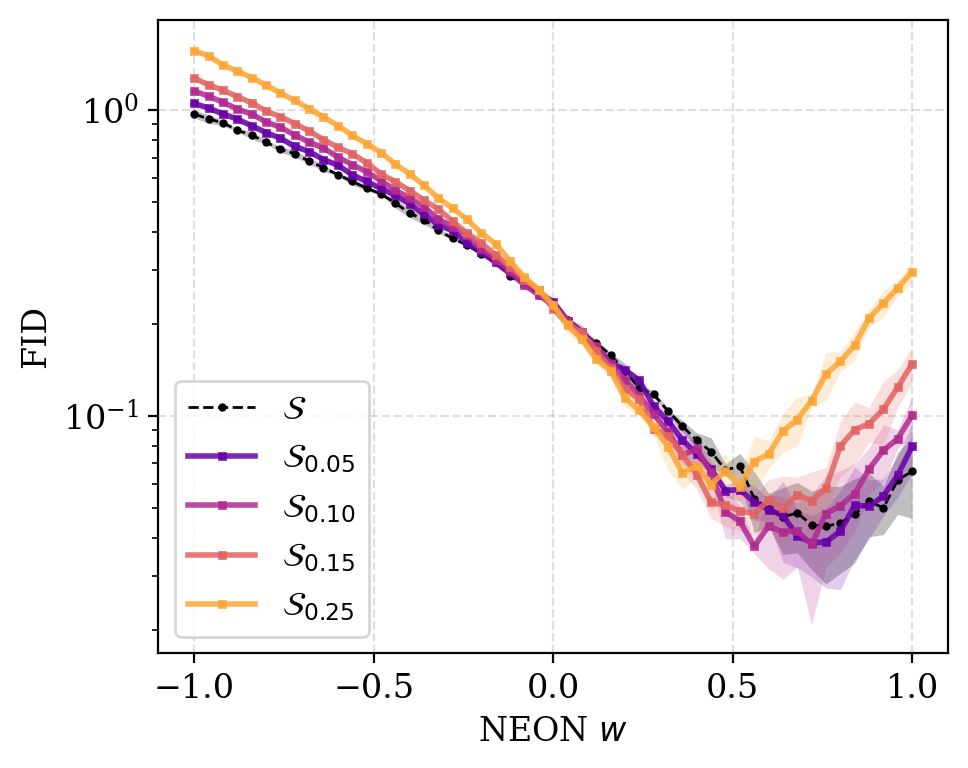

In [15]:
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 10,
    'figure.dpi': 200,
    'savefig.dpi': 200,
    'font.family': 'serif',
})
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4), dpi=200)

# Sort modes so 'full' appears first
max_alpha=0.3
modes = np.array(sorted(df_fid_stats["decode"].unique()))
modes = modes[np.where(modes<=max_alpha)[0]]

# Color map
colors_svd = plt.cm.plasma(np.linspace(0, 0.8, len(modes)))
color_map = {mode: colors_svd[i] for i, mode in enumerate(modes)}
color_map[0.0] = "black"

for alpha in modes:
    if alpha>0.0:
        synthetic_set = rf"$\mathcal{{S}}_{{{alpha.item():.2f}}}$"
    else:
        synthetic_set = rf"$\mathcal{{S}}$"
    df = df_fid_stats[df_fid_stats["decode"] == alpha]
    df = df.sort_values("w")

    is_full = (alpha == 0.0)
    linewidth = 1.0 if is_full else 2.0
    linestyle = "--" if is_full else "-"
    line_alpha = 1.0 if is_full else 0.85
    band_alpha = 0.25 if is_full else 0.20

    color = color_map[alpha]

    # Mean curve
    ax.plot(
        df["w"],
        df["fid_mean"],
        marker="o" if is_full else "s",
        markersize=2,
        label=synthetic_set,
        color=color,
        linewidth=linewidth,
        linestyle=linestyle,
        alpha=line_alpha,
    )

    # Uncertainty band
    ax.fill_between(
        df["w"],
        df["fid_mean"] - df['fid_std'],
        df["fid_mean"] + df['fid_std'],
        color=color,
        alpha=band_alpha,
        linewidth=0,
    )

ax.set_xlabel(r"NEON $w$", fontsize=12)
ax.set_ylabel("FID", fontsize=12)
ax.set_yscale("log")

ax.legend(fontsize=12)
ax.grid(linestyle="--", color="grey", alpha=0.25)

plt.tight_layout()
plt.savefig('neon.pdf')
plt.show()

In [16]:
results = {}

for alpha in ALPHAS:
    print(f"α = {alpha:.3f}")

    S_mean_seeds = []
    S_std_seeds = []
    erank_mean_seeds = []
    erank_std_seeds = []

    for seed in NEON_SEEDS:
        torch.manual_seed(seed)
        np.random.seed(seed)

        # --- Sample latent batch ---
        z_batch = torch.randn(N_aux, D, device=device)

        with torch.no_grad():
            # S_stack: (batch, k)
            # eranks: (batch,)
            S_stack, eranks = decode_batch_collapse_spectrum(
                base_model, z_batch, alpha
            )

        # --- Aggregate over batch ---
        S_mean_seeds.append(S_stack.mean(dim=0))   # (k,)
        S_std_seeds.append(S_stack.std(dim=0))     # (k,)

        erank_mean_seeds.append(eranks.mean())     # scalar
        erank_std_seeds.append(eranks.std())       # scalar

    # --- Stack over seeds ---
    S_mean_seeds = torch.stack(S_mean_seeds)       # (n_seeds, k)
    S_std_seeds = torch.stack(S_std_seeds)         # (n_seeds, k)
    erank_mean_seeds = torch.stack(erank_mean_seeds)
    erank_std_seeds = torch.stack(erank_std_seeds)

    # --- Final aggregation over seeds ---
    results[alpha] = {
        # Singular spectrum statistics
        "S_mean_mean": S_mean_seeds.mean(dim=0),
        "S_mean_std":  S_mean_seeds.std(dim=0),
        "S_std_mean":  S_std_seeds.mean(dim=0),
        "S_std_std":   S_std_seeds.std(dim=0),

        # Effective rank statistics
        "erank_mean_mean": erank_mean_seeds.mean(),
        "erank_mean_std":  erank_mean_seeds.std(),
        "erank_std_mean":  erank_std_seeds.mean(),
        "erank_std_std":   erank_std_seeds.std(),
    }


α = 0.000
α = 0.050
α = 0.100
α = 0.150
α = 0.250
α = 0.400
α = 0.600
α = 1.000


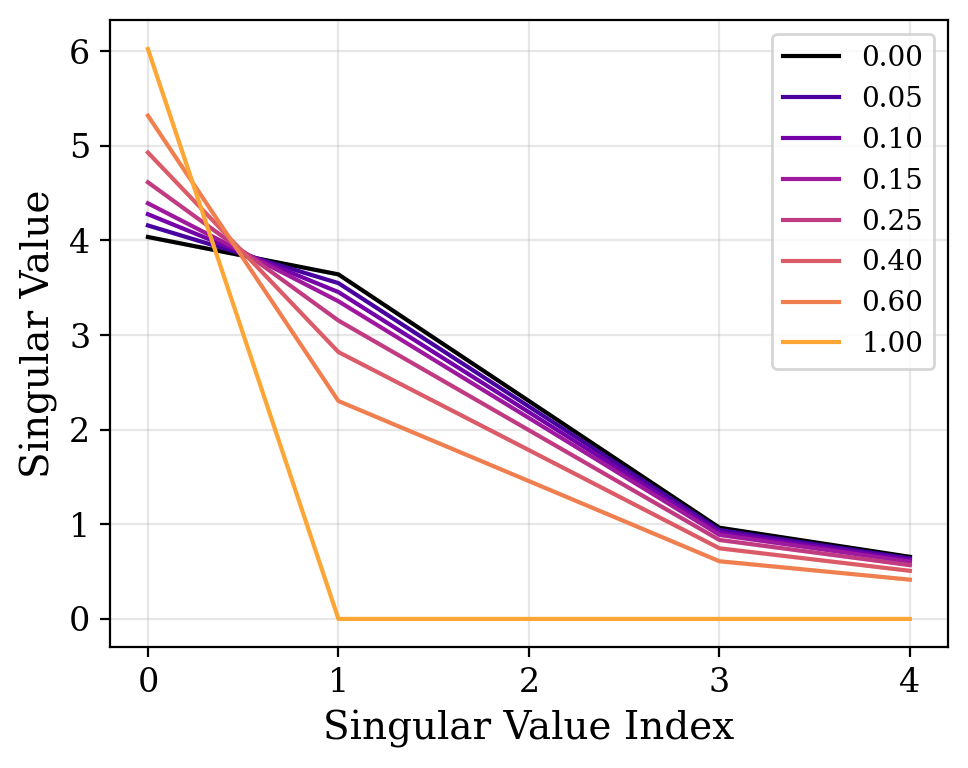

In [17]:
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 10,
    'figure.dpi': 200,
    'savefig.dpi': 200,
    'font.family': 'serif',
})
fig, ax = plt.subplots(figsize=(5, 4), dpi=200)

alphas_sorted = sorted(results.keys())
colors_svd = plt.cm.plasma(np.linspace(0, 0.8, len(alphas_sorted)))
color_map = {mode: colors_svd[i] for i, mode in enumerate(alphas_sorted)}
for alpha in alphas_sorted:
    S_mean = results[alpha]["S_mean_mean"].cpu().numpy()
    S_std  = results[alpha]["S_mean_std"].cpu().numpy()
    idx = np.arange(len(S_mean))
    color=color_map[alpha]
    if alpha==0.0:
        color='black'
    ax.plot(idx, S_mean, color=color, label=f"{alpha:.2f}")
    ax.fill_between(
        idx,
        S_mean - S_std,
        S_mean + S_std,
        color=color,
        alpha=0.25,
    )

ax.set_xlabel("Singular Value Index")
ax.set_ylabel("Singular Value")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('singular_values_alpha.pdf')
plt.show()

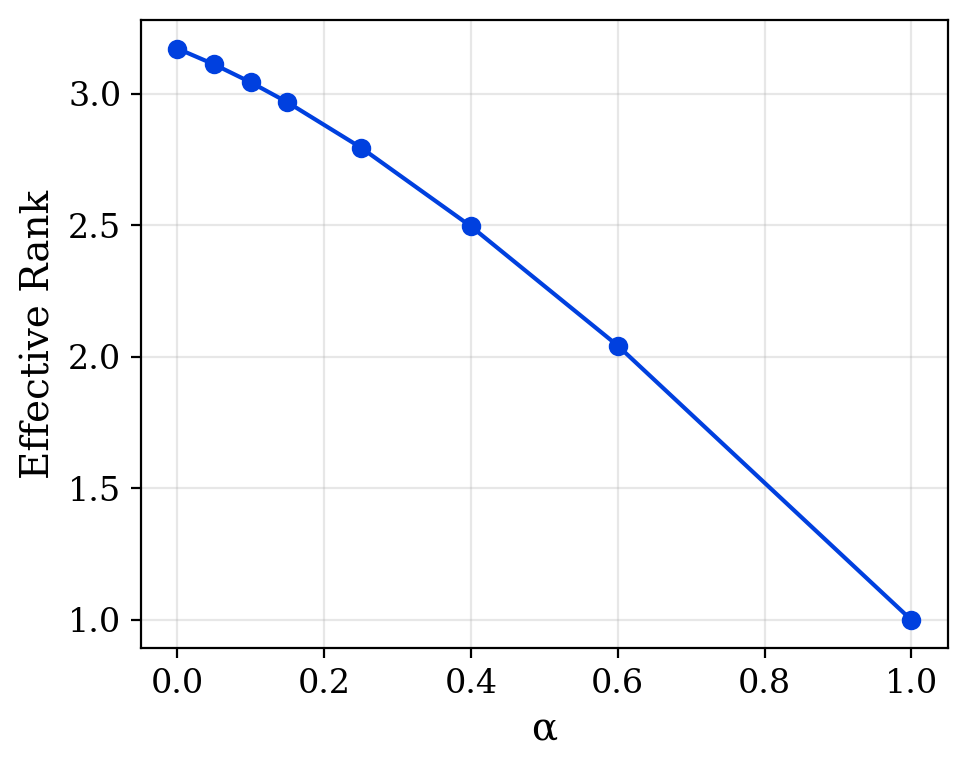

In [18]:
fig, ax = plt.subplots(figsize=(5, 4), dpi=200)

alphas_sorted = sorted(results.keys())
erank_mean = [results[a]["erank_mean_mean"].item() for a in alphas_sorted]
erank_std  = [results[a]["erank_mean_std"].item() for a in alphas_sorted]

ax.plot(alphas_sorted, erank_mean, marker="o", color=plt.cm.winter(0.25))

ax.set_xlabel("α")
ax.set_ylabel("Effective Rank")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('effective_ranks_alpha.pdf')
plt.show()
